In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
)

In [17]:
train_data = fetch_20newsgroups(
subset="train",
remove=("headers", "footers", "quotes")
)

test_data = fetch_20newsgroups(
subset="test",
remove=("headers", "footers", "quotes")
)

X_train_text=train_data.data
y_train=train_data.target

X_test_text=test_data.data
y_test=test_data.target

class_names=train_data. target_names

print("Training documents:",len(X_train_text))
print("Testing documents:",len(X_test_text))
print("Number of classes:", len(class_names))

Training documents: 11314
Testing documents: 7532
Number of classes: 20


In [7]:
vectorizer=CountVectorizer(
stop_words="english",#remove common english words
min_df=2 #keep only words appearing in at least 2 documents
)

X_train=vectorizer.fit_transform(X_train_text)
X_test=vectorizer.transform(X_test_text)

In [18]:
print(f"Training feature matrix: {X_train. shape}")
print(f"Testing feature matrix: {X_test.shape}")

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [19]:
mnb=MultinomialNB()
mnb.fit(X_train, y_train)

y_pred_mnb=mnb.predict(X_test)

binary_vectorizer = CountVectorizer(
stop_words="english",
min_df=2,
binary=True
)
X_train_binary = binary_vectorizer. fit_transform(
X_train_text
)

X_test_binary = binary_vectorizer. transform(
X_test_text
)

In [20]:
bnb = BernoulliNB()

bnb.fit(
X_train_binary,
y_train

)

y_pred_bnb = bnb.predict(
X_test_binary

)

In [24]:
results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
])

models=[
    ("MultinomialNB", mnb, y_pred_mnb),
    ("BernoulliNB", bnb, y_pred_bnb),
]

for name, model, pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, average='weighted'),
        recall_score(y_test, pred, average='weighted'),
        f1_score(y_test, pred, average='weighted'),
    ]

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  MultinomialNB  0.651089   0.642532  0.651089  0.629644
1    BernoulliNB  0.485130   0.627034  0.485130  0.480839


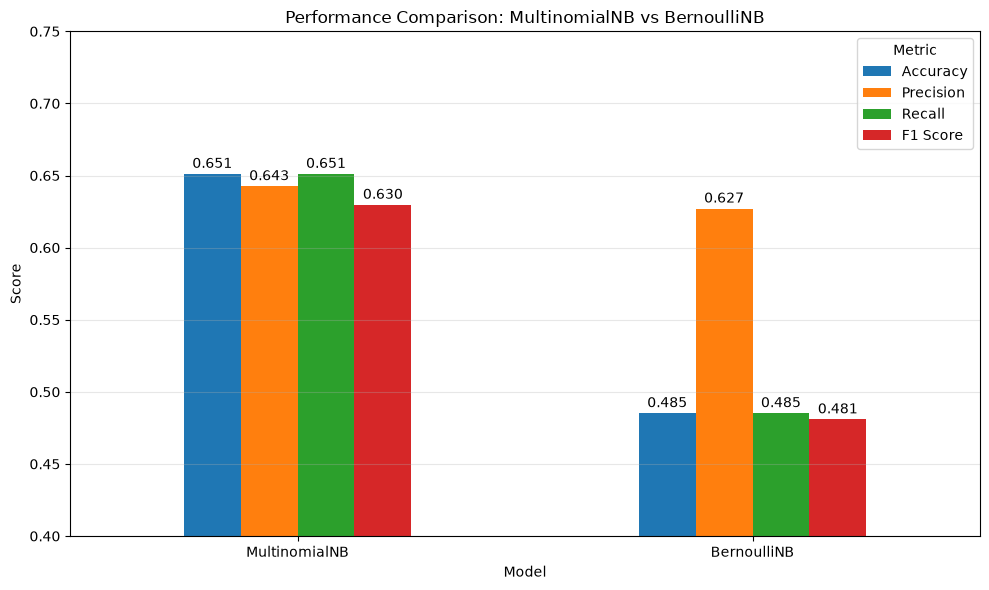

In [25]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison: MultinomialNB vs BernoulliNB")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.40, 0.75) 

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)

plt.tight_layout()
plt.show()